# 05c — Enhanced Dynamic EO-Conditioned Projected Adversarial Fine-Tuning

**Purpose.** This notebook is a new dynamic method only. It does **not** overwrite notebooks 03–05b or their outputs.

## Why this changes the current dynamic method

The existing dynamic notebooks start from ImageNet and use a feature-level linear adversary, \(A(z)\rightarrow s\). This notebook uses a stronger, task-first dynamic strategy:

1. **Baseline initialisation:** load each seed's completed baseline checkpoint.
2. **Conditional-adversary warm-up:** train an Equalized-Odds (EO)-conditioned adversary while the diagnostic model is frozen.
3. **Partial dynamic fine-tuning:** train only ResNet-50 `layer4` and the disease head. Earlier layers stay frozen.
4. **Dynamic projected update:** the adversarial strength is zero for 0.5 fine-tuning epochs, rises smoothly to \(\lambda_{\max}=0.1\) by epoch 3, then remains at 0.1. A gradient projection prevents a disease update from simultaneously helping the adversary.

For each label \(k\), the adversary receives the disease logit and the true label:

\[
A_k(\hat y_k, y_k) \rightarrow s.
\]

This targets the label-conditional dependence relevant to Equalized Odds:

\[
\hat Y_k \perp S \mid Y_k.
\]

**References motivating this design**

- Ganin et al. (2016): gradient-reversal / adversarial representation learning.
- Zhang, Lemoine & Mitchell (2018): Equalized-Odds-conditioned adversary and projection term that avoids predictor updates helping the adversary.
- Correa et al. (2021): two-step adversarial debiasing with partial learning in medical imaging.
- Marcinkevičs et al. (2022): post-hoc fine-tuning of trained chest X-ray classifiers for debiasing.
- Zong et al. (2023): model-selection rules materially affect medical-image fairness outcomes.

## Validation-only selection rule

The existing static model's **validation** EO gap is used as the fairness reference. From fine-tuning epoch 3 onward, select the checkpoint with highest validation macro AUROC among checkpoints satisfying:

\[
EO_{\mathrm{dynamic,val}} \leq EO_{\mathrm{static,val}} + 0.002.
\]

If no checkpoint meets the target, the fallback is the validation checkpoint with the lowest EO gap (then highest AUROC). The test set is never used for selection.


In [8]:

from pathlib import Path
import copy
import json
import math
import re

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import models

from r50_multilabel_final_common import (
    aggregate_multi_seed_table,
    base_run_config,
    build_label_fairness_summary,
    build_loaders,
    compute_test_metrics_by_group,
    ensure_output_dirs,
    get_device,
    load_fixed_multilabel_data,
    make_disease_criterion,
    patient_cluster_bootstrap_multiseed,
    per_label_ranking_metrics,
    safe_auroc,
    save_prediction_archive,
    seed_everything,
    select_per_label_thresholds,
    summarise_overall_fairness,
)

# ------------------------------------------------------------------
# Final protocol. Change these only before the first complete run.
# ------------------------------------------------------------------
FINAL_SEEDS = [42, 123, 2026]
BATCH_SIZE = 16

# Stage 2: train only the EO-conditioned adversary.
ADVERSARY_WARMUP_EPOCHS = 1

# Stage 3: partial dynamic adversarial fine-tuning.
FINE_TUNE_EPOCHS = 8
LAMBDA_MAX = 0.10
ZERO_LAMBDA_EPOCHS = 0.50
RAMP_END_EPOCH = 3.00

# Different learning rates protect the established diagnostic solution.
LAYER4_LR = 1e-5
DISEASE_HEAD_LR = 3e-5
ADVERSARY_LR = 1e-4
WEIGHT_DECAY = 1e-4

# Selection uses validation only. A small tolerance avoids over-interpreting
# small validation-sample fluctuations around the existing static reference.
STATIC_EO_TOLERANCE = 0.002
MIN_SELECTION_EPOCH = math.ceil(RAMP_END_EPOCH)

THRESHOLD_METRIC = "f1"
EXPERIMENT_ID = "r50_dynamic_eo_projected_twostage_multiseed"

# Enable only after all three seed runs complete.
RUN_PATIENT_CLUSTER_BOOTSTRAP = False
N_BOOTSTRAP = 1000
BOOTSTRAP_RANDOM_SEED = 202606

ensure_output_dirs()
Path("figures").mkdir(exist_ok=True)
device = get_device()

print("Device:", device)
print("Experiment:", EXPERIMENT_ID)
print("Seeds:", FINAL_SEEDS)
print(
    "Dynamic lambda: 0 for first "
    f"{ZERO_LAMBDA_EPOCHS} epoch(s), cosine ramp to {LAMBDA_MAX} by "
    f"epoch {RAMP_END_EPOCH}, then hold."
)


Device: mps
Experiment: r50_dynamic_eo_projected_twostage_multiseed
Seeds: [42, 123, 2026]
Dynamic lambda: 0 for first 0.5 epoch(s), cosine ramp to 0.1 by epoch 3.0, then hold.


In [9]:

train_df, val_df, test_df, selected_labels, label_columns, audit_config = load_fixed_multilabel_data()

# Immutable patient-level split checks.
train_patients = set(train_df["Patient ID"].astype(str))
val_patients = set(val_df["Patient ID"].astype(str))
test_patients = set(test_df["Patient ID"].astype(str))
assert train_patients.isdisjoint(val_patients)
assert train_patients.isdisjoint(test_patients)
assert val_patients.isdisjoint(test_patients)

criterion_for_weights, pos_weight_table, pos_weight_values = make_disease_criterion(
    train_df, label_columns, device
)
del criterion_for_weights

print("Selected labels:", selected_labels)
print("Split sizes:", {"train": len(train_df), "validation": len(val_df), "test": len(test_df)})
display(pos_weight_table)


Selected labels: ['Infiltration', 'Effusion', 'Atelectasis', 'Nodule', 'Mass', 'Pneumothorax', 'Consolidation']
Split sizes: {'train': 78873, 'validation': 10953, 'test': 22294}


,label,train_positive,train_negative,pos_weight
0,Infiltration,13868,65005,4.687410
1,Effusion,9533,69340,7.273681
2,Atelectasis,8262,70611,8.546478
3,Nodule,4415,74458,16.864779
4,Mass,4199,74674,17.783758
5,Pneumothorax,3841,75032,19.534496
6,Consolidation,3280,75593,23.046646


In [10]:

class PerLabelEOAdversary(nn.Module):
    """One small conditional adversary per disease label.

    Head k receives [disease_logit_k, true_label_k] and predicts sex.
    This makes the adversarial target label-conditional rather than a global
    request to remove every sex-correlated feature.
    """

    def __init__(self, n_labels: int, hidden_dim: int = 32):
        super().__init__()
        self.n_labels = int(n_labels)
        self.heads = nn.ModuleList(
            [
                nn.Sequential(
                    nn.Linear(2, hidden_dim),
                    nn.ReLU(inplace=True),
                    nn.Linear(hidden_dim, 1),
                )
                for _ in range(self.n_labels)
            ]
        )

    def forward(self, disease_logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        outputs = []
        for label_index, head in enumerate(self.heads):
            conditional_input = torch.stack(
                [disease_logits[:, label_index], targets[:, label_index]], dim=1
            )
            outputs.append(head(conditional_input))
        return torch.cat(outputs, dim=1)


class DynamicEOProjectedResNet50(nn.Module):
    """Baseline-compatible ResNet-50 with a disease head and EO adversaries."""

    def __init__(self, n_labels: int):
        super().__init__()
        self.backbone = models.resnet50(weights=None)
        self.feature_dim = self.backbone.fc.in_features
        if self.feature_dim != 2048:
            raise RuntimeError(f"Unexpected ResNet-50 feature dimension: {self.feature_dim}")
        self.backbone.fc = nn.Identity()
        self.disease_head = nn.Linear(self.feature_dim, n_labels)
        self.eo_adversary = PerLabelEOAdversary(n_labels=n_labels)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        features = self.backbone(x)
        return self.disease_head(features)

    def conditional_sex_logits(
        self,
        disease_logits: torch.Tensor,
        targets: torch.Tensor,
    ) -> torch.Tensor:
        return self.eo_adversary(disease_logits, targets)


def _normalise_checkpoint_keys(state_dict):
    """Remove a possible DataParallel prefix without changing parameter values."""
    if all(key.startswith("module.") for key in state_dict):
        return {key.replace("module.", "", 1): value for key, value in state_dict.items()}
    return state_dict


def load_baseline_checkpoint_into_dynamic_model(model, checkpoint_path: Path, n_labels: int):
    """Load a notebook-03 baseline checkpoint into this expanded dynamic model."""
    payload = torch.load(checkpoint_path, map_location="cpu")
    state_dict = _normalise_checkpoint_keys(payload["model_state_dict"])

    baseline = models.resnet50(weights=None)
    baseline_feature_dim = baseline.fc.in_features
    baseline.fc = nn.Linear(baseline_feature_dim, n_labels)
    missing, unexpected = baseline.load_state_dict(state_dict, strict=False)

    # A valid baseline should not leave backbone or fc weights unmatched.
    disallowed_missing = [key for key in missing if not key.startswith("fc.")]
    if disallowed_missing or unexpected:
        raise RuntimeError(
            "Baseline checkpoint could not be mapped cleanly. "
            f"Missing: {disallowed_missing}; unexpected: {unexpected}"
        )

    backbone_state = {
        key: value for key, value in baseline.state_dict().items() if not key.startswith("fc.")
    }
    missing_backbone, unexpected_backbone = model.backbone.load_state_dict(
        backbone_state, strict=False
    )
    if unexpected_backbone:
        raise RuntimeError(f"Unexpected backbone keys: {unexpected_backbone}")

    model.disease_head.load_state_dict(baseline.fc.state_dict())
    return payload


def set_stage2_trainability(model):
    """Freeze diagnostic model; train EO adversary only."""
    for parameter in model.backbone.parameters():
        parameter.requires_grad = False
    for parameter in model.disease_head.parameters():
        parameter.requires_grad = False
    for parameter in model.eo_adversary.parameters():
        parameter.requires_grad = True

    model.eval()
    model.eo_adversary.train()


def set_stage3_trainability(model):
    """Train layer4 + disease head + EO adversary; freeze lower ResNet stages."""
    frozen_modules = [
        model.backbone.conv1,
        model.backbone.bn1,
        model.backbone.layer1,
        model.backbone.layer2,
        model.backbone.layer3,
    ]
    for module in frozen_modules:
        for parameter in module.parameters():
            parameter.requires_grad = False

    for parameter in model.backbone.layer4.parameters():
        parameter.requires_grad = True
    for parameter in model.disease_head.parameters():
        parameter.requires_grad = True
    for parameter in model.eo_adversary.parameters():
        parameter.requires_grad = True


def set_stage3_train_mode(model):
    """Prevent frozen BatchNorm running-stat drift while training layer4."""
    model.train()
    model.backbone.conv1.eval()
    model.backbone.bn1.eval()
    model.backbone.layer1.eval()
    model.backbone.layer2.eval()
    model.backbone.layer3.eval()
    model.backbone.layer4.train()
    model.disease_head.train()
    model.eo_adversary.train()


def dynamic_lambda_from_finetune_step(global_step: int, steps_per_epoch: int) -> float:
    """Piecewise delayed-cosine dynamic schedule expressed in fine-tuning epochs."""
    epoch_position = global_step / max(steps_per_epoch, 1)
    if epoch_position < ZERO_LAMBDA_EPOCHS:
        return 0.0
    if epoch_position >= RAMP_END_EPOCH:
        return float(LAMBDA_MAX)

    phase = (epoch_position - ZERO_LAMBDA_EPOCHS) / (
        RAMP_END_EPOCH - ZERO_LAMBDA_EPOCHS
    )
    return float(LAMBDA_MAX * 0.5 * (1.0 - math.cos(math.pi * phase)))


def conditional_sex_targets(sexes: torch.Tensor, n_labels: int) -> torch.Tensor:
    return sexes.float().unsqueeze(1).expand(-1, n_labels)


def evaluate_dynamic_eo_model(model, loader, disease_criterion, sex_criterion, device, labels):
    """Evaluate disease outputs and conditional EO-adversary diagnostics."""
    model.eval()
    total_disease_loss = total_adv_loss = 0.0
    prob_batches, target_batches, sex_batches = [], [], []
    patient_id_batches, image_index_batches = [], []
    conditional_adv_prob_batches = []

    with torch.no_grad():
        for images, targets, sexes, patient_ids, image_indices in loader:
            images = images.to(device)
            targets = targets.to(device)
            sex_targets = conditional_sex_targets(sexes.to(device), len(labels))

            disease_logits = model(images)
            adv_logits = model.conditional_sex_logits(disease_logits, targets)

            disease_loss = disease_criterion(disease_logits, targets)
            adv_loss = sex_criterion(adv_logits, sex_targets)

            total_disease_loss += disease_loss.item() * images.size(0)
            total_adv_loss += adv_loss.item() * images.size(0)
            prob_batches.append(torch.sigmoid(disease_logits).cpu().numpy())
            target_batches.append(targets.cpu().numpy())
            sex_batches.append(sexes.numpy())
            patient_id_batches.append(list(patient_ids))
            image_index_batches.append(list(image_indices))
            conditional_adv_prob_batches.append(torch.sigmoid(adv_logits).cpu().numpy())

    probs = np.concatenate(prob_batches, axis=0)
    targets_np = np.concatenate(target_batches, axis=0)
    sexes_np = np.concatenate(sex_batches, axis=0).astype(int)
    conditional_adv_probs = np.concatenate(conditional_adv_prob_batches, axis=0)

    label_metrics = per_label_ranking_metrics(targets_np, probs, labels)
    mean_conditional_adv_prob = conditional_adv_probs.mean(axis=1)
    n = len(loader.dataset)

    return {
        "probs": probs,
        "targets": targets_np,
        "sexes": sexes_np,
        "patient_ids": np.asarray(
            [item for batch in patient_id_batches for item in batch], dtype=str
        ),
        "image_indices": np.asarray(
            [item for batch in image_index_batches for item in batch], dtype=str
        ),
        # Retained for prediction-archive compatibility; it is a conditional
        # adversary diagnostic, not a feature-level sex probe.
        "sex_probs": mean_conditional_adv_prob,
        "conditional_adversary_sex_auroc": safe_auroc(sexes_np, mean_conditional_adv_prob),
        "disease_loss": float(total_disease_loss / n),
        "conditional_adv_loss": float(total_adv_loss / n),
        "disease_macro_auroc": float(np.nanmean(label_metrics["AUROC"])),
        "disease_macro_auprc": float(np.nanmean(label_metrics["AUPRC"])),
        "label_metrics": label_metrics,
    }


def validation_fairness_from_result(result, labels):
    """Fit F1 thresholds on this validation prediction set and calculate validation EO."""
    thresholds_df = select_per_label_thresholds(
        probs=result["probs"],
        targets=result["targets"],
        labels=labels,
        metric=THRESHOLD_METRIC,
    )
    overall_metrics, subgroup_metrics = compute_test_metrics_by_group(
        probs=result["probs"],
        targets=result["targets"],
        sexes=result["sexes"],
        labels=labels,
        thresholds_df=thresholds_df,
    )
    fairness_by_label = build_label_fairness_summary(
        overall_metrics=overall_metrics,
        subgroup_metrics=subgroup_metrics,
        model_name="validation_dynamic_eo",
    )
    return thresholds_df, summarise_overall_fairness(fairness_by_label)


def find_static_validation_eo(seed: int, labels):
    """Read the existing static model's validation archive and validation thresholds.

    The function supports the output naming used by notebook 04 and falls back
    to a broad filename search to avoid any manual renaming.
    """
    result_dir = Path("results")
    candidate_archives = list(result_dir.glob(f"r50_static_grl_seed{seed}_validation_predictions.npz"))
    candidate_archives += list(result_dir.glob(f"*static*seed{seed}*validation_predictions.npz"))
    candidate_archives = list(dict.fromkeys(candidate_archives))

    for archive_path in candidate_archives:
        prefix = str(archive_path).replace("_validation_predictions.npz", "")
        threshold_path = Path(f"{prefix}_thresholds.csv")
        if not threshold_path.exists():
            continue

        archive = np.load(archive_path, allow_pickle=False)
        thresholds_df = pd.read_csv(threshold_path)
        archive_labels = [str(value) for value in archive["labels"].tolist()]
        if archive_labels != list(labels):
            continue

        overall_metrics, subgroup_metrics = compute_test_metrics_by_group(
            probs=archive["probs"],
            targets=archive["targets"],
            sexes=archive["sexes"].astype(int),
            labels=labels,
            thresholds_df=thresholds_df,
        )
        fairness = summarise_overall_fairness(
            build_label_fairness_summary(
                overall_metrics=overall_metrics,
                subgroup_metrics=subgroup_metrics,
                model_name="static_validation_reference",
            )
        )
        return float(fairness["mean_Equalized_Odds_gap"]), str(archive_path)

    return None, None


In [11]:

def train_adversary_warmup_epoch(
    model,
    loader,
    optimizer_adversary,
    sex_criterion,
    device,
    n_labels,
):
    """Stage 2: learn conditional sex prediction while the diagnostic model is frozen."""
    set_stage2_trainability(model)
    total_loss = 0.0

    for images, targets, sexes, _, _ in loader:
        images = images.to(device)
        targets = targets.to(device)
        sex_targets = conditional_sex_targets(sexes.to(device), n_labels)

        optimizer_adversary.zero_grad(set_to_none=True)
        with torch.no_grad():
            disease_logits = model(images)
        adv_logits = model.conditional_sex_logits(disease_logits.detach(), targets)
        adv_loss = sex_criterion(adv_logits, sex_targets)
        adv_loss.backward()
        optimizer_adversary.step()

        total_loss += adv_loss.item() * images.size(0)

    return float(total_loss / len(loader.dataset))


def train_projected_dynamic_epoch(
    model,
    loader,
    optimizer_predictor,
    optimizer_adversary,
    disease_criterion,
    sex_criterion,
    device,
    n_labels,
    global_step,
):
    """Stage 3: projected dynamic EO-conditioned adversarial optimisation.

    For shared predictor parameters theta:
        g_task = grad L_disease
        g_adv  = grad L_EO-adversary

    When g_task would reduce the adversary loss, project out that component;
    then add the dynamic adversarial direction -lambda_t * g_adv.
    """
    set_stage3_trainability(model)

    shared_parameters = [
        parameter
        for parameter in list(model.backbone.layer4.parameters())
        + list(model.disease_head.parameters())
        if parameter.requires_grad
    ]
    adversary_parameters = list(model.eo_adversary.parameters())

    total_disease_loss = total_adv_loss = 0.0
    lambda_values, cosine_values = [], []
    schedule_rows = []

    for batch_index, (images, targets, sexes, _, _) in enumerate(loader, start=1):
        set_stage3_train_mode(model)

        images = images.to(device)
        targets = targets.to(device)
        sex_targets = conditional_sex_targets(sexes.to(device), n_labels)

        lambda_current = dynamic_lambda_from_finetune_step(
            global_step=global_step,
            steps_per_epoch=len(loader),
        )

        # ----- Predictor update, with frozen adversary parameters -----
        optimizer_predictor.zero_grad(set_to_none=True)
        for parameter in adversary_parameters:
            parameter.requires_grad = False

        disease_logits = model(images)
        adv_logits = model.conditional_sex_logits(disease_logits, targets)
        disease_loss = disease_criterion(disease_logits, targets)
        adv_loss_for_predictor = sex_criterion(adv_logits, sex_targets)

        task_grads = torch.autograd.grad(
            disease_loss,
            shared_parameters,
            retain_graph=True,
            allow_unused=True,
        )
        adv_grads = torch.autograd.grad(
            adv_loss_for_predictor,
            shared_parameters,
            retain_graph=False,
            allow_unused=True,
        )

        task_grads = [
            gradient if gradient is not None else torch.zeros_like(parameter)
            for gradient, parameter in zip(task_grads, shared_parameters)
        ]
        adv_grads = [
            gradient if gradient is not None else torch.zeros_like(parameter)
            for gradient, parameter in zip(adv_grads, shared_parameters)
        ]

        dot_product = sum((task * adv).sum() for task, adv in zip(task_grads, adv_grads))
        adv_norm_sq = sum((adv * adv).sum() for adv in adv_grads)
        task_norm_sq = sum((task * task).sum() for task in task_grads)

        # At lambda=0, preserve the baseline task update exactly.
        # Once adversarial training begins, remove only task components that would
        # help the adversary and then reverse the adversarial gradient dynamically.
        if lambda_current > 0.0 and adv_norm_sq.item() > 0.0:
            projection_scale = torch.clamp(dot_product, min=0.0) / (adv_norm_sq + 1e-12)
        else:
            projection_scale = torch.tensor(0.0, device=device)

        for parameter, task_gradient, adv_gradient in zip(
            shared_parameters, task_grads, adv_grads
        ):
            projected_task_gradient = task_gradient - projection_scale * adv_gradient
            combined_gradient = projected_task_gradient - lambda_current * adv_gradient
            parameter.grad = combined_gradient

        optimizer_predictor.step()

        cosine = (
            dot_product / (torch.sqrt(task_norm_sq * adv_norm_sq) + 1e-12)
            if task_norm_sq.item() > 0.0 and adv_norm_sq.item() > 0.0
            else torch.tensor(np.nan, device=device)
        )

        # ----- Adversary update on the latest predictor outputs -----
        for parameter in adversary_parameters:
            parameter.requires_grad = True

        # Keep the predictor in evaluation mode here so an adversary-only pass
        # does not alter BatchNorm running statistics.
        model.eval()
        model.eo_adversary.train()
        optimizer_adversary.zero_grad(set_to_none=True)
        with torch.no_grad():
            refreshed_logits = model(images)
        refreshed_adv_logits = model.conditional_sex_logits(
            refreshed_logits.detach(), targets
        )
        adversary_loss = sex_criterion(refreshed_adv_logits, sex_targets)
        adversary_loss.backward()
        optimizer_adversary.step()

        total_disease_loss += disease_loss.item() * images.size(0)
        total_adv_loss += adversary_loss.item() * images.size(0)
        lambda_values.append(float(lambda_current))
        cosine_values.append(float(cosine.detach().cpu()))
        schedule_rows.append(
            {
                "batch": int(batch_index),
                "global_step": int(global_step),
                "fine_tune_epoch_position": float(global_step / max(len(loader), 1)),
                "lambda_adv": float(lambda_current),
                "task_adv_gradient_cosine": float(cosine.detach().cpu()),
                "projection_active": bool(lambda_current > 0.0 and dot_product.item() > 0.0),
            }
        )
        global_step += 1

    n = len(loader.dataset)
    return {
        "disease_loss": float(total_disease_loss / n),
        "adversary_loss": float(total_adv_loss / n),
        "lambda_start": float(lambda_values[0]),
        "lambda_end": float(lambda_values[-1]),
        "lambda_mean": float(np.mean(lambda_values)),
        "mean_task_adv_gradient_cosine": float(np.nanmean(cosine_values)),
        "global_step": int(global_step),
        "schedule_rows": schedule_rows,
    }


In [12]:

def run_enhanced_dynamic_seed(seed: int):
    seed_everything(seed)
    run_tag = f"r50_dynamic_eo_projected_twostage_seed{seed}"
    output_prefix = Path("results") / run_tag
    best_model_path = Path("checkpoints") / f"{run_tag}_best.pt"
    fallback_model_path = Path("checkpoints") / f"{run_tag}_fallback_lowest_eo.pt"
    baseline_checkpoint_path = Path("checkpoints") / f"r50_baseline_final_seed{seed}_best.pt"

    if not baseline_checkpoint_path.exists():
        raise FileNotFoundError(
            f"Missing baseline checkpoint: {baseline_checkpoint_path}. "
            "Run notebook 03 first or confirm its filename."
        )

    train_loader, val_loader, test_loader = build_loaders(
        train_df=train_df,
        val_df=val_df,
        test_df=test_df,
        label_columns=label_columns,
        seed=seed,
        batch_size=BATCH_SIZE,
    )

    model = DynamicEOProjectedResNet50(n_labels=len(selected_labels)).to(device)
    baseline_payload = load_baseline_checkpoint_into_dynamic_model(
        model, baseline_checkpoint_path, n_labels=len(selected_labels)
    )

    disease_criterion, _, _ = make_disease_criterion(train_df, label_columns, device)
    sex_criterion = nn.BCEWithLogitsLoss()

    # Baseline validation fairness is calculated directly from the loaded baseline
    # predictions, with baseline-specific validation thresholds.
    set_stage2_trainability(model)
    baseline_val = evaluate_dynamic_eo_model(
        model, val_loader, disease_criterion, sex_criterion, device, selected_labels
    )
    baseline_val_thresholds, baseline_val_fairness = validation_fairness_from_result(
        baseline_val, selected_labels
    )

    static_val_eo, static_reference_archive = find_static_validation_eo(seed, selected_labels)
    if static_val_eo is None:
        # This fallback keeps the protocol runnable if the old static artefact has
        # a different filename. It is deliberately reported in the run config.
        selection_target_eo = 0.90 * baseline_val_fairness["mean_Equalized_Odds_gap"]
        selection_reference = "fallback: 10% validation EO reduction vs baseline"
    else:
        selection_target_eo = static_val_eo + STATIC_EO_TOLERANCE
        selection_reference = (
            "existing static validation EO gap + tolerance "
            f"({STATIC_EO_TOLERANCE:.3f})"
        )

    optimizer_adversary = torch.optim.AdamW(
        model.eo_adversary.parameters(),
        lr=ADVERSARY_LR,
        weight_decay=WEIGHT_DECAY,
    )

    warmup_rows = []
    for warmup_epoch in range(1, ADVERSARY_WARMUP_EPOCHS + 1):
        warmup_loss = train_adversary_warmup_epoch(
            model=model,
            loader=train_loader,
            optimizer_adversary=optimizer_adversary,
            sex_criterion=sex_criterion,
            device=device,
            n_labels=len(selected_labels),
        )
        warmup_rows.append(
            {"seed": seed, "stage": "adversary_warmup", "epoch": warmup_epoch, "loss": warmup_loss}
        )
        print(f"Seed {seed} | Stage 2 adversary warm-up {warmup_epoch}/{ADVERSARY_WARMUP_EPOCHS} | loss={warmup_loss:.4f}")

    set_stage3_trainability(model)
    optimizer_predictor = torch.optim.AdamW(
        [
            {"params": model.backbone.layer4.parameters(), "lr": LAYER4_LR},
            {"params": model.disease_head.parameters(), "lr": DISEASE_HEAD_LR},
        ],
        weight_decay=WEIGHT_DECAY,
    )
    # Recreate after stage-2 warm-up to keep its state, but ensure the parameter
    # references remain correct and explicit for Stage 3.
    optimizer_adversary = torch.optim.AdamW(
        model.eo_adversary.parameters(),
        lr=ADVERSARY_LR,
        weight_decay=WEIGHT_DECAY,
    )

    run_config = base_run_config(
        seed=seed,
        selected_labels=selected_labels,
        feature_dim=model.feature_dim,
        batch_size=BATCH_SIZE,
        num_epochs=ADVERSARY_WARMUP_EPOCHS + FINE_TUNE_EPOCHS,
        pos_weight_values=pos_weight_values,
        checkpoint_path=best_model_path,
    )
    run_config.update(
        {
            "experiment_id": EXPERIMENT_ID,
            "model_variant": "r50_dynamic_eo_projected_twostage",
            "baseline_initialisation_checkpoint": str(baseline_checkpoint_path),
            "stage2": "frozen diagnostic model; conditional EO-adversary warm-up",
            "stage2_epochs": int(ADVERSARY_WARMUP_EPOCHS),
            "stage3": "partial dynamic EO-conditioned projected adversarial fine-tuning",
            "trainable_stage3": ["ResNet-50 layer4", "disease head", "per-label EO adversary"],
            "frozen_stage3": ["conv1", "bn1", "layer1", "layer2", "layer3"],
            "eo_adversary": "seven MLPs: [disease_logit_k, true_label_k] -> sex",
            "gradient_projection": (
                "remove task-gradient component that reduces conditional adversary loss, "
                "then apply -lambda(t)*adversarial gradient"
            ),
            "lambda_max": float(LAMBDA_MAX),
            "zero_lambda_epochs": float(ZERO_LAMBDA_EPOCHS),
            "ramp_end_epoch": float(RAMP_END_EPOCH),
            "learning_rates": {
                "layer4": float(LAYER4_LR),
                "disease_head": float(DISEASE_HEAD_LR),
                "eo_adversary": float(ADVERSARY_LR),
            },
            "selection_rule": (
                "from fine-tuning epoch >= "
                f"{MIN_SELECTION_EPOCH}, highest validation macro AUROC with "
                "validation mean EO gap <= selection target; ties use macro AUPRC "
                "then worst-group recall"
            ),
            "selection_target_eo": float(selection_target_eo),
            "selection_reference": selection_reference,
            "static_validation_reference_archive": static_reference_archive,
            "baseline_validation_mean_EO_gap": float(
                baseline_val_fairness["mean_Equalized_Odds_gap"]
            ),
            "static_validation_mean_EO_gap": (
                None if static_val_eo is None else float(static_val_eo)
            ),
            "threshold_metric": f"validation_{THRESHOLD_METRIC}",
            "test_set_hyperparameter_policy": "No test-set selection, tuning, or threshold optimisation.",
        }
    )

    print(f"\n{'=' * 78}\nStarting {run_tag}")
    print("Baseline checkpoint:", baseline_checkpoint_path)
    print("Baseline validation EO:", baseline_val_fairness["mean_Equalized_Odds_gap"])
    print("Static validation EO:", static_val_eo)
    print("Selection target EO:", selection_target_eo)
    print("Selection reference:", selection_reference)

    history = []
    schedule_rows = []
    global_step = 0
    best_eligible = None
    best_fallback = None

    for epoch in range(1, FINE_TUNE_EPOCHS + 1):
        train_results = train_projected_dynamic_epoch(
            model=model,
            loader=train_loader,
            optimizer_predictor=optimizer_predictor,
            optimizer_adversary=optimizer_adversary,
            disease_criterion=disease_criterion,
            sex_criterion=sex_criterion,
            device=device,
            n_labels=len(selected_labels),
            global_step=global_step,
        )
        global_step = train_results["global_step"]
        for row in train_results["schedule_rows"]:
            row.update({"seed": seed, "fine_tune_epoch": epoch, "model_variant": run_config["model_variant"]})
        schedule_rows.extend(train_results["schedule_rows"])

        val_results = evaluate_dynamic_eo_model(
            model, val_loader, disease_criterion, sex_criterion, device, selected_labels
        )
        _, val_fairness = validation_fairness_from_result(val_results, selected_labels)

        record = {
            "seed": seed,
            "fine_tune_epoch": epoch,
            "lambda_start": train_results["lambda_start"],
            "lambda_end": train_results["lambda_end"],
            "lambda_mean": train_results["lambda_mean"],
            "train_disease_loss": train_results["disease_loss"],
            "train_conditional_adv_loss": train_results["adversary_loss"],
            "mean_task_adv_gradient_cosine": train_results["mean_task_adv_gradient_cosine"],
            "val_disease_loss": val_results["disease_loss"],
            "val_conditional_adv_loss": val_results["conditional_adv_loss"],
            "val_macro_auroc": val_results["disease_macro_auroc"],
            "val_macro_auprc": val_results["disease_macro_auprc"],
            "val_conditional_adversary_sex_auroc": val_results["conditional_adversary_sex_auroc"],
            **{f"val_{key}": float(value) for key, value in val_fairness.items()},
        }
        history.append(record)

        eligible = (
            epoch >= MIN_SELECTION_EPOCH
            and val_fairness["mean_Equalized_Odds_gap"] <= selection_target_eo
        )

        candidate_key = (
            float(val_results["disease_macro_auroc"]),
            float(val_results["disease_macro_auprc"]),
            float(val_fairness["mean_Worst_group_Recall"]),
        )
        fallback_key = (
            -float(val_fairness["mean_Equalized_Odds_gap"]),
            float(val_results["disease_macro_auroc"]),
            float(val_results["disease_macro_auprc"]),
        )

        if epoch >= MIN_SELECTION_EPOCH and (
            best_fallback is None or fallback_key > best_fallback["key"]
        ):
            best_fallback = {
                "key": fallback_key,
                "epoch": epoch,
                "val_macro_auroc": float(val_results["disease_macro_auroc"]),
                "val_macro_auprc": float(val_results["disease_macro_auprc"]),
                "val_eo_gap": float(val_fairness["mean_Equalized_Odds_gap"]),
            }
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "epoch": int(epoch),
                    "selection_status": "fallback_lowest_validation_EO",
                    "run_config": run_config,
                },
                fallback_model_path,
            )

        if eligible and (best_eligible is None or candidate_key > best_eligible["key"]):
            best_eligible = {
                "key": candidate_key,
                "epoch": epoch,
                "val_macro_auroc": float(val_results["disease_macro_auroc"]),
                "val_macro_auprc": float(val_results["disease_macro_auprc"]),
                "val_eo_gap": float(val_fairness["mean_Equalized_Odds_gap"]),
            }
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "epoch": int(epoch),
                    "selection_status": "matched_static_validation_EO",
                    "run_config": run_config,
                },
                best_model_path,
            )

        print(
            f"Seed {seed} | FT epoch {epoch}/{FINE_TUNE_EPOCHS} | "
            f"lambda={train_results['lambda_start']:.4f}->{train_results['lambda_end']:.4f} | "
            f"val AUROC={val_results['disease_macro_auroc']:.4f} | "
            f"val AUPRC={val_results['disease_macro_auprc']:.4f} | "
            f"val EO={val_fairness['mean_Equalized_Odds_gap']:.4f} | "
            f"eligible={eligible}"
        )

    if best_eligible is not None:
        selected_checkpoint_path = best_model_path
        selected = best_eligible
        selection_status = "matched_static_validation_EO"
    elif best_fallback is not None:
        selected_checkpoint_path = fallback_model_path
        selected = best_fallback
        selection_status = "fallback_lowest_validation_EO_no_match"
    else:
        raise RuntimeError("No selectable checkpoint was created after dynamic ramp completion.")

    checkpoint = torch.load(selected_checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model = model.to(device).eval()

    val_final = evaluate_dynamic_eo_model(
        model, val_loader, disease_criterion, sex_criterion, device, selected_labels
    )
    test_final = evaluate_dynamic_eo_model(
        model, test_loader, disease_criterion, sex_criterion, device, selected_labels
    )

    thresholds_df = select_per_label_thresholds(
        probs=val_final["probs"],
        targets=val_final["targets"],
        labels=selected_labels,
        metric=THRESHOLD_METRIC,
    )
    test_overall_by_label, test_subgroup_metrics = compute_test_metrics_by_group(
        probs=test_final["probs"],
        targets=test_final["targets"],
        sexes=test_final["sexes"],
        labels=selected_labels,
        thresholds_df=thresholds_df,
    )
    label_fairness_summary = build_label_fairness_summary(
        overall_metrics=test_overall_by_label,
        subgroup_metrics=test_subgroup_metrics,
        model_name=run_config["model_variant"],
    )
    fairness_means = summarise_overall_fairness(label_fairness_summary)

    for frame in [test_overall_by_label, test_subgroup_metrics, label_fairness_summary]:
        frame.insert(0, "seed", seed)
        frame.insert(0, "model_variant", run_config["model_variant"])

    history_df = pd.DataFrame(history)
    schedule_df = pd.DataFrame(schedule_rows)

    overall_result = pd.DataFrame(
        [{
            "model_variant": run_config["model_variant"],
            "model": run_config["model_variant"],
            "seed": seed,
            "n_labels": len(selected_labels),
            "selected_labels": "|".join(selected_labels),
            "lambda_max": float(LAMBDA_MAX),
            "best_epoch": int(selected["epoch"]),
            "selection_status": selection_status,
            "selection_target_validation_EO_gap": float(selection_target_eo),
            "selected_validation_EO_gap": float(selected["val_eo_gap"]),
            "best_val_macro_auroc": float(selected["val_macro_auroc"]),
            "best_val_macro_auprc": float(selected["val_macro_auprc"]),
            "test_macro_auroc": float(test_final["disease_macro_auroc"]),
            "test_macro_auprc": float(test_final["disease_macro_auprc"]),
            "test_conditional_adversary_sex_auroc": float(
                test_final["conditional_adversary_sex_auroc"]
            ),
            **fairness_means,
        }]
    )

    pos_weight_table.to_csv(f"{output_prefix}_pos_weights.csv", index=False)
    pd.DataFrame(warmup_rows).to_csv(f"{output_prefix}_adversary_warmup.csv", index=False)
    history_df.to_csv(f"{output_prefix}_training_history.csv", index=False)
    schedule_df.to_csv(f"{output_prefix}_lambda_schedule_stepwise.csv", index=False)
    thresholds_df.to_csv(f"{output_prefix}_thresholds.csv", index=False)
    test_overall_by_label.to_csv(f"{output_prefix}_test_label_metrics.csv", index=False)
    test_subgroup_metrics.to_csv(f"{output_prefix}_subgroup_metrics.csv", index=False)
    label_fairness_summary.to_csv(f"{output_prefix}_label_fairness_summary.csv", index=False)
    overall_result.to_csv(f"{output_prefix}_overall_results.csv", index=False)

    run_config.update(
        {
            "selected_checkpoint": str(selected_checkpoint_path),
            "selected_epoch": int(selected["epoch"]),
            "selection_status": selection_status,
            "selected_validation_EO_gap": float(selected["val_eo_gap"]),
            "selected_validation_macro_auroc": float(selected["val_macro_auroc"]),
            "selected_validation_macro_auprc": float(selected["val_macro_auprc"]),
            "test_macro_auroc": float(test_final["disease_macro_auroc"]),
            "test_macro_auprc": float(test_final["disease_macro_auprc"]),
            "test_mean_EO_gap": float(fairness_means["mean_Equalized_Odds_gap"]),
        }
    )
    with open(f"{output_prefix}_run_config.json", "w", encoding="utf-8") as handle:
        json.dump(run_config, handle, indent=2)

    save_prediction_archive(
        f"{output_prefix}_validation_predictions.npz",
        val_final,
        selected_labels,
        adversarial=True,
    )
    save_prediction_archive(
        f"{output_prefix}_test_predictions.npz",
        test_final,
        selected_labels,
        adversarial=True,
    )

    print(f"\nCompleted {run_tag}")
    print("Selection status:", selection_status)
    print("Selected fine-tuning epoch:", selected["epoch"])
    print("Test macro AUROC:", test_final["disease_macro_auroc"])
    print("Test macro AUPRC:", test_final["disease_macro_auprc"])
    print("Test mean EO gap:", fairness_means["mean_Equalized_Odds_gap"])
    display(overall_result)

    return {
        "seed": seed,
        "output_prefix": str(output_prefix),
        "overall_result": overall_result,
        "test_label_metrics": test_overall_by_label,
        "subgroup_metrics": test_subgroup_metrics,
        "label_fairness_summary": label_fairness_summary,
        "schedule": schedule_df,
    }


In [13]:
seed_runs = [run_enhanced_dynamic_seed(seed) for seed in FINAL_SEEDS]

Seed 42 | Stage 2 adversary warm-up 1/1 | loss=0.6873

Starting r50_dynamic_eo_projected_twostage_seed42
Baseline checkpoint: checkpoints/r50_baseline_final_seed42_best.pt
Baseline validation EO: 0.07119805005648597
Static validation EO: 0.08553865780283638
Selection target EO: 0.08753865780283639
Selection reference: existing static validation EO gap + tolerance (0.002)
Seed 42 | FT epoch 1/8 | lambda=0.0000->0.0095 | val AUROC=0.8106 | val AUPRC=0.3040 | val EO=0.0767 | eligible=False
Seed 42 | FT epoch 2/8 | lambda=0.0095->0.0654 | val AUROC=0.8099 | val AUPRC=0.3010 | val EO=0.0867 | eligible=False
Seed 42 | FT epoch 3/8 | lambda=0.0655->0.1000 | val AUROC=0.8072 | val AUPRC=0.2987 | val EO=0.0782 | eligible=True
Seed 42 | FT epoch 4/8 | lambda=0.1000->0.1000 | val AUROC=0.8038 | val AUPRC=0.2933 | val EO=0.0589 | eligible=True
Seed 42 | FT epoch 5/8 | lambda=0.1000->0.1000 | val AUROC=0.8031 | val AUPRC=0.2908 | val EO=0.0783 | eligible=True
Seed 42 | FT epoch 6/8 | lambda=0.1000-

,model_variant,model,seed,n_labels,selected_labels,lambda_max,best_epoch,selection_status,selection_target_validation_EO_gap,selected_validation_EO_gap,best_val_macro_auroc,best_val_macro_auprc,test_macro_auroc,test_macro_auprc,test_conditional_adversary_sex_auroc,mean_FNR_gap,mean_FPR_gap,mean_Equalized_Odds_gap,mean_Worst_group_Recall,mean_AUROC_gap
0,r50_dynamic_eo_projected_twostage,r50_dynamic_eo_projected_twostage,42,7,Infiltration|Effusion|Atelectasis|Nodule|Mass|...,0.1,3,matched_static_validation_EO,0.087539,0.078173,0.80716,0.298673,0.810101,0.307364,0.526431,0.025248,0.008895,0.026099,0.466655,0.013728


Seed 123 | Stage 2 adversary warm-up 1/1 | loss=0.6831

Starting r50_dynamic_eo_projected_twostage_seed123
Baseline checkpoint: checkpoints/r50_baseline_final_seed123_best.pt
Baseline validation EO: 0.08048508255434648
Static validation EO: 0.07394029023318452
Selection target EO: 0.07594029023318452
Selection reference: existing static validation EO gap + tolerance (0.002)
Seed 123 | FT epoch 1/8 | lambda=0.0000->0.0095 | val AUROC=0.8127 | val AUPRC=0.2999 | val EO=0.0584 | eligible=False
Seed 123 | FT epoch 2/8 | lambda=0.0095->0.0654 | val AUROC=0.8119 | val AUPRC=0.2988 | val EO=0.0693 | eligible=False
Seed 123 | FT epoch 3/8 | lambda=0.0655->0.1000 | val AUROC=0.8128 | val AUPRC=0.2972 | val EO=0.0703 | eligible=True
Seed 123 | FT epoch 4/8 | lambda=0.1000->0.1000 | val AUROC=0.8091 | val AUPRC=0.2922 | val EO=0.0715 | eligible=True
Seed 123 | FT epoch 5/8 | lambda=0.1000->0.1000 | val AUROC=0.8096 | val AUPRC=0.2924 | val EO=0.0677 | eligible=True
Seed 123 | FT epoch 6/8 | lambd

,model_variant,model,seed,n_labels,selected_labels,lambda_max,best_epoch,selection_status,selection_target_validation_EO_gap,selected_validation_EO_gap,best_val_macro_auroc,best_val_macro_auprc,test_macro_auroc,test_macro_auprc,test_conditional_adversary_sex_auroc,mean_FNR_gap,mean_FPR_gap,mean_Equalized_Odds_gap,mean_Worst_group_Recall,mean_AUROC_gap
0,r50_dynamic_eo_projected_twostage,r50_dynamic_eo_projected_twostage,123,7,Infiltration|Effusion|Atelectasis|Nodule|Mass|...,0.1,3,matched_static_validation_EO,0.07594,0.070329,0.812822,0.297218,0.810083,0.310031,0.537248,0.034565,0.013254,0.034565,0.463018,0.012107


Seed 2026 | Stage 2 adversary warm-up 1/1 | loss=0.6857

Starting r50_dynamic_eo_projected_twostage_seed2026
Baseline checkpoint: checkpoints/r50_baseline_final_seed2026_best.pt
Baseline validation EO: 0.0777841904776808
Static validation EO: 0.052390313187620254
Selection target EO: 0.054390313187620255
Selection reference: existing static validation EO gap + tolerance (0.002)
Seed 2026 | FT epoch 1/8 | lambda=0.0000->0.0095 | val AUROC=0.8118 | val AUPRC=0.3044 | val EO=0.0572 | eligible=False
Seed 2026 | FT epoch 2/8 | lambda=0.0095->0.0654 | val AUROC=0.8090 | val AUPRC=0.3009 | val EO=0.0592 | eligible=False
Seed 2026 | FT epoch 3/8 | lambda=0.0655->0.1000 | val AUROC=0.8070 | val AUPRC=0.2984 | val EO=0.0548 | eligible=False
Seed 2026 | FT epoch 4/8 | lambda=0.1000->0.1000 | val AUROC=0.8055 | val AUPRC=0.2930 | val EO=0.0578 | eligible=False
Seed 2026 | FT epoch 5/8 | lambda=0.1000->0.1000 | val AUROC=0.8028 | val AUPRC=0.2898 | val EO=0.0532 | eligible=True
Seed 2026 | FT epoch

,model_variant,model,seed,n_labels,selected_labels,lambda_max,best_epoch,selection_status,selection_target_validation_EO_gap,selected_validation_EO_gap,best_val_macro_auroc,best_val_macro_auprc,test_macro_auroc,test_macro_auprc,test_conditional_adversary_sex_auroc,mean_FNR_gap,mean_FPR_gap,mean_Equalized_Odds_gap,mean_Worst_group_Recall,mean_AUROC_gap
0,r50_dynamic_eo_projected_twostage,r50_dynamic_eo_projected_twostage,2026,7,Infiltration|Effusion|Atelectasis|Nodule|Mass|...,0.1,5,matched_static_validation_EO,0.05439,0.053226,0.802801,0.289755,0.806672,0.303624,0.543652,0.034005,0.012593,0.034005,0.439396,0.015973


,model_variant,best_epoch_mean,best_val_macro_auroc_mean,best_val_macro_auprc_mean,test_macro_auroc_mean,test_macro_auprc_mean,mean_FNR_gap_mean,mean_FPR_gap_mean,mean_Equalized_Odds_gap_mean,mean_Worst_group_Recall_mean,...,best_epoch_n_seeds,best_val_macro_auroc_n_seeds,best_val_macro_auprc_n_seeds,test_macro_auroc_n_seeds,test_macro_auprc_n_seeds,mean_FNR_gap_n_seeds,mean_FPR_gap_n_seeds,mean_Equalized_Odds_gap_n_seeds,mean_Worst_group_Recall_n_seeds,mean_AUROC_gap_n_seeds
0,r50_dynamic_eo_projected_twostage,3.666667,0.807594,0.295215,0.808952,0.307006,0.031273,0.011581,0.031556,0.456356,...,3,3,3,3,3,3,3,3,3,3


,seed,selection_status,best_epoch,best_val_macro_auroc,best_val_macro_auprc,selected_validation_EO_gap,selection_target_validation_EO_gap,test_macro_auroc,test_macro_auprc,mean_Equalized_Odds_gap
0,42,matched_static_validation_EO,3,0.807160,0.298673,0.078173,0.087539,0.810101,0.307364,0.026099
1,123,matched_static_validation_EO,3,0.812822,0.297218,0.070329,0.075940,0.810083,0.310031,0.034565
2,2026,matched_static_validation_EO,5,0.802801,0.289755,0.053226,0.054390,0.806672,0.303624,0.034005


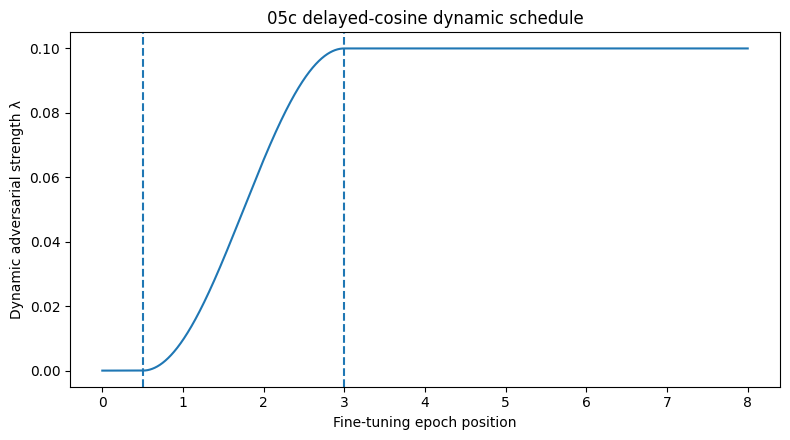

In [14]:

overall_all = pd.concat([run["overall_result"] for run in seed_runs], ignore_index=True)
label_metrics_all = pd.concat([run["test_label_metrics"] for run in seed_runs], ignore_index=True)
subgroup_metrics_all = pd.concat([run["subgroup_metrics"] for run in seed_runs], ignore_index=True)
label_fairness_all = pd.concat([run["label_fairness_summary"] for run in seed_runs], ignore_index=True)
schedule_all = pd.concat([run["schedule"] for run in seed_runs], ignore_index=True)

summary_prefix = Path("results") / "r50_dynamic_eo_projected_twostage_multiseed"
overall_all.to_csv(f"{summary_prefix}_seed_level_overall_results.csv", index=False)
label_metrics_all.to_csv(f"{summary_prefix}_seed_level_test_label_metrics.csv", index=False)
subgroup_metrics_all.to_csv(f"{summary_prefix}_seed_level_subgroup_metrics.csv", index=False)
label_fairness_all.to_csv(f"{summary_prefix}_seed_level_label_fairness.csv", index=False)
schedule_all.to_csv(f"{summary_prefix}_lambda_schedule_stepwise.csv", index=False)

overall_summary = aggregate_multi_seed_table(
    overall_all,
    group_columns=["model_variant"],
    metric_columns=[
        "best_epoch",
        "best_val_macro_auroc",
        "best_val_macro_auprc",
        "test_macro_auroc",
        "test_macro_auprc",
        "mean_FNR_gap",
        "mean_FPR_gap",
        "mean_Equalized_Odds_gap",
        "mean_Worst_group_Recall",
        "mean_AUROC_gap",
    ],
)
overall_summary.to_csv(f"{summary_prefix}_overall_mean_std.csv", index=False)

display(overall_summary)
display(overall_all[[
    "seed", "selection_status", "best_epoch",
    "best_val_macro_auroc", "best_val_macro_auprc",
    "selected_validation_EO_gap", "selection_target_validation_EO_gap",
    "test_macro_auroc", "test_macro_auprc", "mean_Equalized_Odds_gap",
]])

schedule_summary = (
    schedule_all.groupby(["global_step", "fine_tune_epoch_position"], as_index=False)
    .agg(
        lambda_adv_mean=("lambda_adv", "mean"),
        lambda_adv_std=("lambda_adv", "std"),
        gradient_cosine_mean=("task_adv_gradient_cosine", "mean"),
    )
)
schedule_summary.to_csv(f"{summary_prefix}_lambda_schedule_mean_std.csv", index=False)

plt.figure(figsize=(8, 4.5))
plt.plot(schedule_summary["fine_tune_epoch_position"], schedule_summary["lambda_adv_mean"])
plt.axvline(ZERO_LAMBDA_EPOCHS, linestyle="--")
plt.axvline(RAMP_END_EPOCH, linestyle="--")
plt.xlabel("Fine-tuning epoch position")
plt.ylabel("Dynamic adversarial strength λ")
plt.title("05c delayed-cosine dynamic schedule")
plt.tight_layout()
plt.savefig("figures/r50_dynamic_eo_projected_twostage_lambda_schedule.png", dpi=300)
plt.show()


In [15]:

if RUN_PATIENT_CLUSTER_BOOTSTRAP:
    bootstrap_archives = []
    for run in seed_runs:
        prefix = Path(run["output_prefix"])
        archive = np.load(f"{prefix}_test_predictions.npz", allow_pickle=False)
        bootstrap_archives.append(
            {
                "seed": run["seed"],
                "probs": archive["probs"],
                "targets": archive["targets"],
                "sexes": archive["sexes"],
                "patient_ids": archive["patient_ids"],
                "image_indices": archive["image_indices"],
                "labels": archive["labels"],
                "thresholds_df": pd.read_csv(f"{prefix}_thresholds.csv"),
            }
        )

    bootstrap_distribution, bootstrap_ci, bootstrap_seed_points = (
        patient_cluster_bootstrap_multiseed(
            bootstrap_archives,
            n_bootstrap=N_BOOTSTRAP,
            random_seed=BOOTSTRAP_RANDOM_SEED,
        )
    )
    bootstrap_distribution.to_csv(f"{summary_prefix}_patient_cluster_bootstrap_distribution.csv", index=False)
    bootstrap_ci.to_csv(f"{summary_prefix}_patient_cluster_bootstrap_ci.csv", index=False)
    bootstrap_seed_points.to_csv(f"{summary_prefix}_patient_cluster_bootstrap_seed_points.csv", index=False)
    display(bootstrap_ci)
else:
    print("Bootstrap disabled. Set RUN_PATIENT_CLUSTER_BOOTSTRAP=True after all seeds complete.")


Bootstrap disabled. Set RUN_PATIENT_CLUSTER_BOOTSTRAP=True after all seeds complete.
